# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

**Aluno:** Marcos Carvalho Ferreira - **Matrícula:** 2026160060

# Atividade Prática 01

**Instruções:**
1. Siga os passos indicados em cada célula abaixo para completar a atividade.
2. Você deve inserir código somente entre as linhas marcadas com **INICIE O CÓDIGO AQUI** e **TERMINE O CÓDIGO AQUI**. Há uma indicação de quantas linhas de código são necessárias.
3. Em alguns pontos, confira o resultado esperado conforme marcado com **SAÍDA ESPERADA**.

**Tempo estimado para execução**: 2,0 horas

Versão: Maio, 2024

## O Problema a ser Resolvido

O objetivo da atividade é elaborar modelos baseados em Redes Neurais Recorrentes para a tarefa de classificação de textos. Classificação de texto é uma tarefa de PLN que atribui um rótulo (ou classe) a um texto. <br>

Nesta atividade, você vai usar um dataset de mensagens de texto, e o seu modelo vai predizer aquelas que são *spam* e as que não são *spam* (*ham*). Este é um problema de classificação binária. <br>

Você vai praticar as seguintes habilidades:
- Preprocessar os dados
- Usar as bibliotecas de Redes Neurais Recorrentes
- Configurar arquiteturas de redes neurais usando camadas LSTM e GRU
- Treinar modelos para classificação das mensagens
- Avaliar os modelos treinados

Referências: <br>
Código adaptado de:<br>
https://nzlul.medium.com/the-classification-of-text-messages-using-lstm-bi-lstm-and-gru-f79b207f90ad<br>
Documentação da API Keras para Camadas Recorrentes:<br>
https://keras.io/api/layers/recurrent_layers/<br>
https://www.tensorflow.org/guide/keras/working_with_rnns<br>

## Pacotes

In [55]:
#%pip install seaborn

In [4]:
# Load, explore and plot data
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
%matplotlib inline
# Train test split
from sklearn.model_selection import train_test_split
# Text pre-processing
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
# Modeling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Embedding, Dropout, GlobalAveragePooling1D, Flatten, SpatialDropout1D, Bidirectional

2026-09-17 18:09:03.930326: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-17 18:09:03.951490: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-17 18:09:04.203298: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-17 18:09:04.203622: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-17 18:09:04.205141: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

## Pré-Processamento dos Dados

### Dataset

Base de dados de mensagens SMS de celulares, publicamente disponível na UCL datasets (https://archive.ics.uci.edu/dataset/228/sms+spam+collection). Pode também ser baixada de https://raw.githubusercontent.com/kenneth-lee-ch/SMS-Spam-Classification/master/spam.csv<br>
O dataset contém 5.574 mensagens rotuladas como *spam* ou não *spam* (*ham*).

A biblioteca Pandas foi usada para ler e manipular o dataset.

In [5]:
# read the dataset
df = pd.read_csv('./datasets/spam.csv', encoding='ISO-8859-1')
# rename the columns
df = df[['v1','v2']]
df.rename(columns={'v1':'label', 'v2':'message'}, inplace=True)
# show the first instances
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Estatísticas sobre os Dados

Exibe um sumário das estatísticas para melhor entender os dados

In [6]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [7]:
df.groupby('label').describe().T

label                              ham  \
message count                     4825   
        unique                    4516   
        top     Sorry, I'll call later   
        freq                        30   

label                                                        spam  
message count                                                 747  
        unique                                                653  
        top     Please call our customer service representativ...  
        freq                                                    4

### Nuvem de Palavras

Visualiza as palavras mais frequentes em cada classe usando uma nuvem de palavras

In [8]:
ham_msg  = df.loc[df['label'] == 'ham']
spam_msg = df.loc[df['label'] == 'spam']

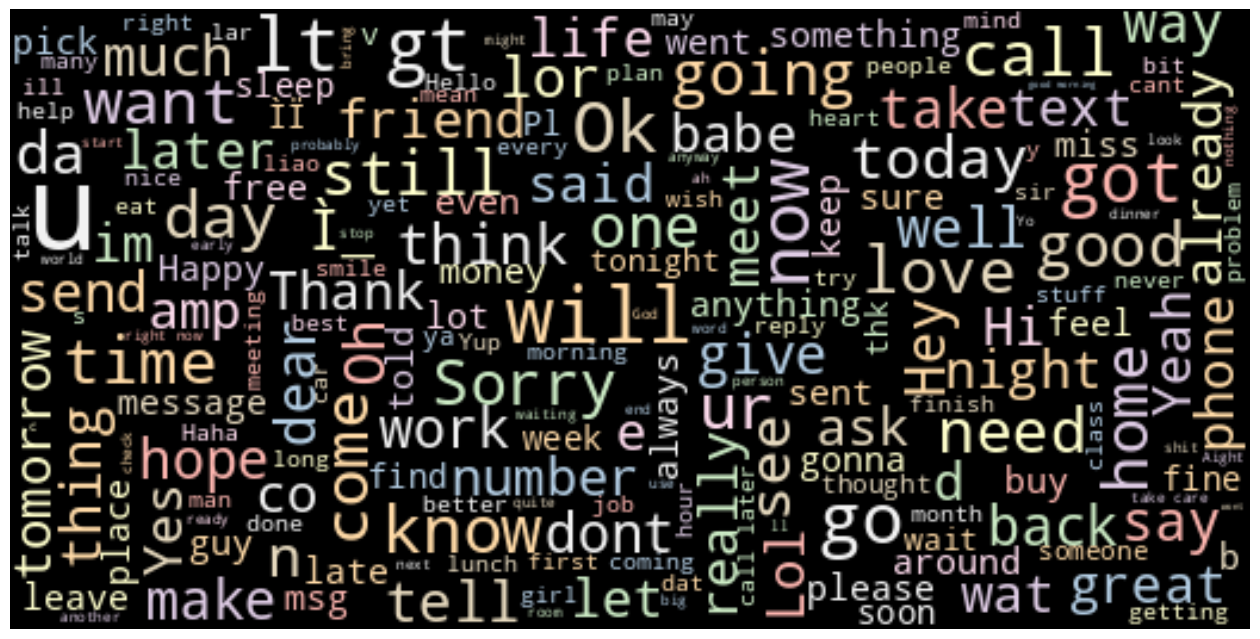

In [9]:
# Nuvem de palavras da classe 'ham'
ham_msg_text = ' '.join(ham_msg['message'])
ham_msg_cloud = WordCloud(width =520, height =260, stopwords = STOPWORDS, max_font_size = 50, background_color = "black", colormap = 'Pastel1').generate(ham_msg_text)
plt.figure(figsize=(16,10))
plt.imshow(ham_msg_cloud, interpolation = 'bilinear')
plt.axis('off') # turn off axis
plt.show()

Palavras mais frequentes da classe 'ham', de acordo com a nuvem de palavras: now, will, ok, today, Sorry etc.

Adicione abaixo um trecho de código para gerar a nuvem de palavras para os textos da classe 'spam'.<br>
Depois, verifique as palavras mais frequentes da classe.

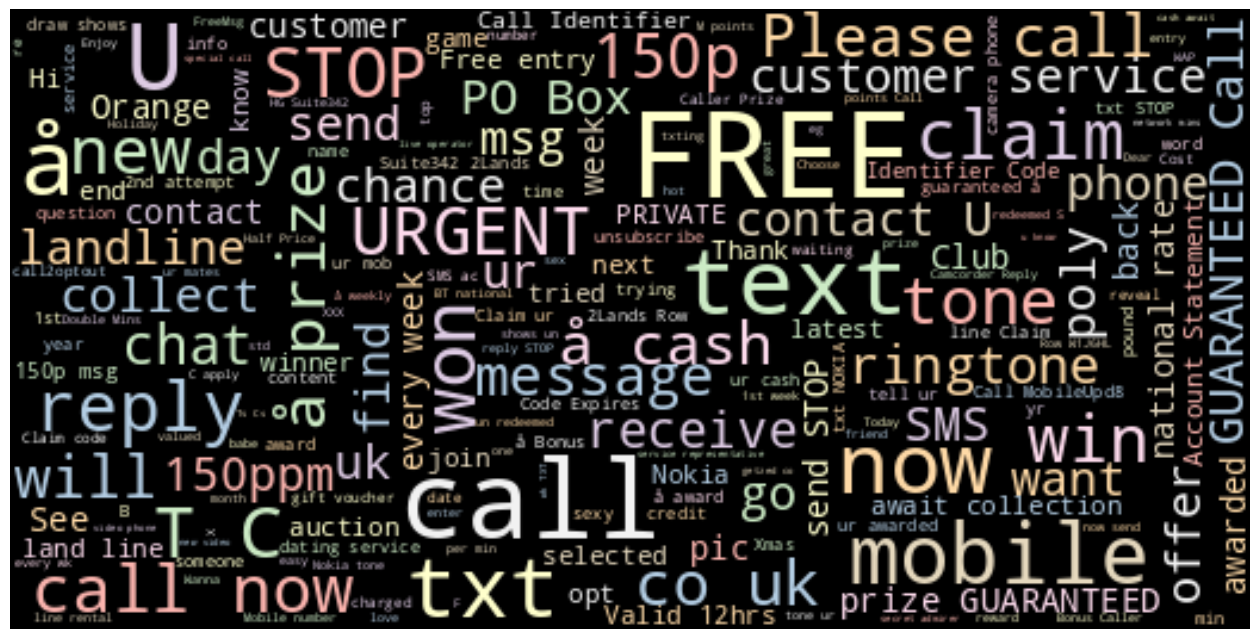

In [10]:
# Nuvem de palavras da classe 'spam'
### INICIE O CÓDIGO AQUI ### (6 ou mais linhas de código)
spam_msg_text = ' '.join(spam_msg['message'])
spam_msg_cloud = WordCloud(width =520, height =260, stopwords = STOPWORDS, max_font_size = 50, background_color = "black", colormap = 'Pastel1').generate(spam_msg_text)
plt.figure(figsize=(16,10))
plt.imshow(spam_msg_cloud, interpolation = 'bilinear')
plt.axis('off') # turn off axis
plt.show()
### TERMINE O CÓDIGO AQUI ###

Palavras mais frequentes da classe 'spam', de acordo com a nuvem de palavras: FREE, call, URGENT, mobile, etc

### Balanceamento dos Dados

Como veremos abaixo, o dataset está muito desbalanceado. Existem muito mais mensagens na classe 'ham' do que na classe 'spam'.<br>
O treinamento de modelos de aprendizagem de máquina a partir de datasets muito desbalanceados pode gerar um viés, levando o modelo a predizer a classe mais frequente.<br>

Existem algumas abordagens para tratar o problema de dados desbalanceados, dentre elas: escolher métricas de avaliação mais apropriadas, resampling (oversampling and undersampling), Synthetic Minority Oversampling Technique (SMOTE), BalancedBaggingClassifier, Threshold moving.<br>

Neste notebook, nós usaremos o método undersampling (subamostragem) para manusear os dados desbalanceados. A técnica consiste em subamostrar a classe majoritária de forma aleatória e uniforme, escolhendo, aproximadamente, o mesmo número de instâncias da classe minoritária. Isso pode potenciamente conduzir a perda de informação, mas se os exemplos da classe majoritária estiverem próximos uns aos outros, esse método pode levar a bons resultados.

Text(0.5, 1.0, 'The distribution of ham and spam messages')

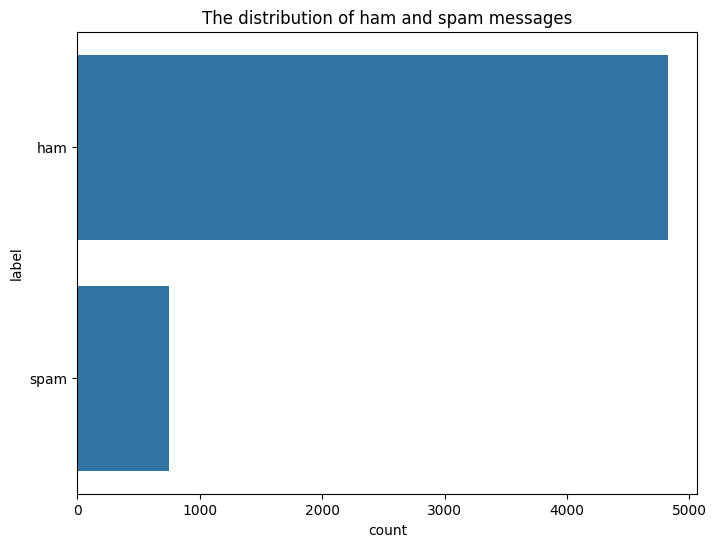

In [11]:
# Distribuição das mensagens em 'ham' e 'spam'
plt.figure(figsize=(8,6))
sns.countplot(df.label)
plt.title('The distribution of ham and spam messages')

In [12]:
# downsample the ham msg
ham_msg_df = ham_msg.sample(n = len(spam_msg), random_state = 44)

In [13]:
msg_df = pd.concat([ham_msg_df, spam_msg])
msg_df.head()

,label,message
3234,ham,"Yes, princess. Toledo."
3804,ham,Dude while were makin those weirdy brownies my...
2701,ham,"Hiya, sorry didn't hav signal. I haven't seen ..."
2822,ham,Then u ask darren go n pick u lor... But i oso...
5161,ham,Lol no. I just need to cash in my nitros. Hurr...


In [14]:
msg_df.tail()

,label,message
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...
5567,spam,This is the 2nd time we have tried 2 contact u...


Text(0.5, 1.0, 'The distribution of ham and spam messages')

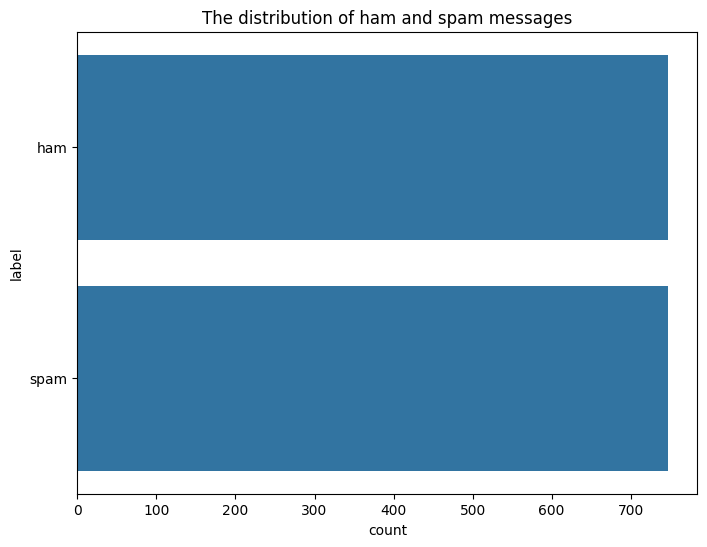

In [15]:
# Nova distribuição
plt.figure(figsize=(8,6))
sns.countplot(msg_df.label)
plt.title('The distribution of ham and spam messages')

### Pré-processamento do Texto

Cria duas colunas no *dataframe*: uma para armazenar o comprimento de cada mensagem de texto e outra para armazenar o rótulo da classe convertido para um valor numérico (0: ham, 1: spam).

In [16]:
# Get length column for each text
msg_df['text_length'] = msg_df['message'].apply(len)
# Get the converted numeric label of the data
msg_df['msg_type'] = msg_df['label'].map({'ham':0, 'spam':1})
msg_df.head()

,label,message,text_length,msg_type
3234,ham,"Yes, princess. Toledo.",22,0
3804,ham,Dude while were makin those weirdy brownies my...,88,0
2701,ham,"Hiya, sorry didn't hav signal. I haven't seen ...",169,0
2822,ham,Then u ask darren go n pick u lor... But i oso...,74,0
5161,ham,Lol no. I just need to cash in my nitros. Hurr...,75,0


In [17]:
msg_df.tail()

,label,message,text_length,msg_type
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...,90,1
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,160,1
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...,160,1
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...,147,1
5567,spam,This is the 2nd time we have tried 2 contact u...,161,1


### Divisão dos Dados em Treino e Teste

Os dados são divididos, aletatoriamente, em 80% para treino e 20% para teste.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(msg_df['message'], msg_df['msg_type'], test_size=0.2, random_state=434)

In [19]:
X_train.tail()

1364    Hey i will be really pretty late... You want t...
1121    Do you want 750 anytime any network mins 150 t...
4458    Welcome to UK-mobile-date this msg is FREE giv...
2900    Ur cash-balance is currently 500 pounds - to m...
5269    If you don't, your prize will go to another cu...
Name: message, dtype: object

In [20]:
y_train.tail()

1364    0
1121    1
4458    1
2900    1
5269    1
Name: msg_type, dtype: int64

### Tokenização

Os textos das mensagens precisam ser convertidos para uma representação numérica, para que o modelo possa entendê-los.

A API Tokenizer do TensorFlow divide as sentenças em palavras e as codifica em números inteiros.

O Tokenizer executará os seguintes passos de pré-processamento: tokeniza a nível de palavras, remove os termos de pontuação, converte todas as palavras para minúsculas, converte todas as palavras para números inteiros. Os seguintes parâmetros foram definidos:
- num_words: número de palavras únicas (vocabulário)
- oov_token: token usado para substituir palavras que não estiverem no vocabulário

In [21]:
# Defining pre-processing parameters
max_len = 50 
trunc_type = 'post'
padding_type = 'post'
oov_tok = '<OOV>' # out of vocabulary token
vocab_size = 500

In [22]:
tokenizer = Tokenizer(num_words = vocab_size, 
                      char_level = False,
                      oov_token = oov_tok)
tokenizer.fit_on_texts(X_train)

In [23]:
# Get the word_index
word_index = tokenizer.word_index
total_words = len(word_index)
total_words

4054

Em seguida, cada sentença é representada por uma sequência de números usando o método texts_to_sequences do objeto Tokenizer.

Depois, cada setença é completada com o token de 'pad' ou truncada para que todas tenham o mesmo comprimento.

Os parâmetros são:
- maxlen: tamanho máximo de todas as sequências. O valor *default* é o comprimento da sentença mais longa.
- padding: 'pre' ou 'post' (*default*). Completa com tokens 'pad' antes ('pre') ou depois ('post') de cada sequencia.
- truncating: 'pre' ou 'post' (*default*). Se o tamanho de uma sentença for maior do que o valor de 'maxlen', ela será truncada para 'maxlen'. A opção 'pre' trunca no início e 'post' trunca no final da sequência.

In [24]:
# Dados de treino
training_sequences = tokenizer.texts_to_sequences(X_train)
training_padded = pad_sequences(training_sequences,
                                maxlen = max_len,
                                padding = padding_type,
                                truncating = trunc_type)

In [25]:
# Dados de teste
testing_sequences = tokenizer.texts_to_sequences(X_test)
testing_padded = pad_sequences(testing_sequences,
                               maxlen = max_len,
                               padding = padding_type,
                               truncating = trunc_type)

In [26]:
# Formato dos tensores de treino e teste
print('Shape of training tensor: ', training_padded.shape)
print('Shape of testing tensor: ', testing_padded.shape)

Shape of training tensor:  (1195, 50)
Shape of testing tensor:  (299, 50)


## Configuração do Modelo de Classificação

Define a arquitetura do modelo de classificação. O modelo usa uma Rede Neural Recorrente do tipo LSTM (Long Short Term Memory) Bidirecional.

O modelo sequencial Keras permite a adição de camadas em uma sequência. Você deve adicionar as seguintes camadas em sequência:
- Camada de Embedding, que mapeia cada palavra para um vetor N-dimensional de número reais. O 'embedding_dim' é o tamanho do vetor, nesse caso, 16. Como a camada de embedding é a primeira camada oculta do modelo, a camada de entrada deve ser definida por input_length = max_len.
- Camada LSTM bidirecional, com 128 unidades.
- Camada de Dropout com uma fração de drop = 0.2
- Camada Densa (camada de classificação binária) com uma unidade e função de ativação sigmoid.

In [27]:
embedding_dim = 16  # tamanho do embedding (vetor) de palavras
n_lstm = 128        # número de unidades (dimensionalidade da saída)
drop_lstm = 0.2     # fração das unidades para drop

In [28]:
model = Sequential()
model.add(Embedding(vocab_size,
                    embedding_dim,
                    input_length = max_len))
### INICIE O CÓDIGO AQUI ### (3 linhas de código)
model.add(Bidirectional(LSTM(n_lstm)))
model.add(Dropout(drop_lstm))
model.add(Dense(1, activation='sigmoid'))
### TERMINE O CÓDIGO AQUI ###

2026-09-17 18:09:14.896951: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-17 18:09:14.898793: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2211] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Exibe um sumário do modelo

In [29]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 16)            8000      
                                                                 
 bidirectional (Bidirection  (None, 256)               148480    
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense (Dense)               (None, 1)                 257       
                                                                 
Total params: 156737 (612.25 KB)
Trainable params: 156737 (612.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**SAÍDA ESPERADA:** <br>

Compila o modelo Keras para configurar o processo de treinamento

In [30]:
model.compile(loss = 'binary_crossentropy',
              optimizer = 'adam',
              metrics=['accuracy'])

## Treinamento do Modelo

Treina o modelo de classificação usando o método 'fit'.

EarlyStopping (monitor='val_loss', patience=2) define que o método vai monitorar a perda nos dados de validação, e se a perda não for melhorada após 2 épocas, então o modelo de treinamento é finalizado. Essa técnica ajuda a evitar problemas de *overfitting*.

In [31]:
num_epochs = 30
early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 2)
history = model.fit(training_padded,
                    y_train,
                    epochs = num_epochs,
                    validation_data = (testing_padded, y_test),
                    callbacks = [early_stop],
                    verbose = 2)

Epoch 1/30
38/38 - 3s - loss: 0.6263 - accuracy: 0.6544 - val_loss: 0.6190 - val_accuracy: 0.6522 - 3s/epoch - 71ms/step
Epoch 2/30
38/38 - 1s - loss: 0.3574 - accuracy: 0.8669 - val_loss: 0.2555 - val_accuracy: 0.9164 - 574ms/epoch - 15ms/step
Epoch 3/30
38/38 - 1s - loss: 0.1895 - accuracy: 0.9322 - val_loss: 0.1457 - val_accuracy: 0.9465 - 594ms/epoch - 16ms/step
Epoch 4/30
38/38 - 1s - loss: 0.1349 - accuracy: 0.9582 - val_loss: 0.1742 - val_accuracy: 0.9331 - 591ms/epoch - 16ms/step
Epoch 5/30
38/38 - 1s - loss: 0.1146 - accuracy: 0.9623 - val_loss: 0.1223 - val_accuracy: 0.9599 - 626ms/epoch - 16ms/step
Epoch 6/30
38/38 - 1s - loss: 0.0944 - accuracy: 0.9682 - val_loss: 0.1526 - val_accuracy: 0.9197 - 763ms/epoch - 20ms/step
Epoch 7/30
38/38 - 1s - loss: 0.1426 - accuracy: 0.9423 - val_loss: 0.1932 - val_accuracy: 0.9431 - 807ms/epoch - 21ms/step


Plota gráficos de acurácia e perda

In [32]:
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

(0.0, 0.6529338423162698)

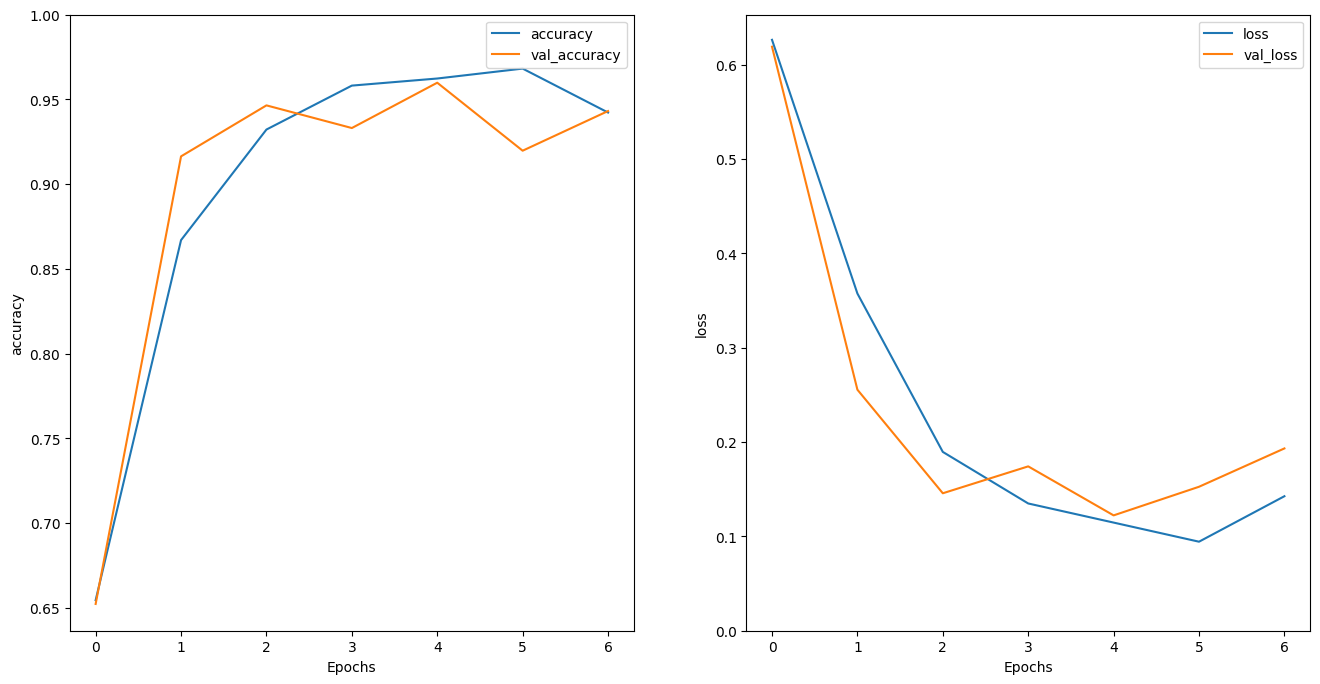

In [33]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

## Avaliação do Modelo

Avalia o desempenho do modelo no conjunto de teste.

In [34]:
loss_lstm1, acc_lstm1 = model.evaluate(testing_padded, y_test)
print(f"LSTM model loss: {loss_lstm1} " )
print(f"LSTM model accuracy: {acc_lstm1*100:0.2f}%" )

10/10 [==============================] - 0s 6ms/step - loss: 0.1932 - accuracy: 0.9431
LSTM model loss: 0.19321872293949127 
LSTM model accuracy: 94.31%


## Predição

Prediz a saída de novas mensagens

In [35]:
predict_msg = ["Have friends and colleagues who could benefit from these weekly updates? Send them to this link to subscribe",
               "Call me"]

In [36]:
def predict_spam(predict_msg):
  new_seq = tokenizer.texts_to_sequences(predict_msg)
  padded = pad_sequences(new_seq,
                         maxlen = max_len,
                         padding = padding_type,
                         truncating = trunc_type)
  return(model.predict(padded))

In [37]:
# 'ham' se predict < 0.5 senão 'spam'
predict_spam(predict_msg)

1/1 [==============================] - 0s 351ms/step


array([[0.998096  ],
       [0.00983778]], dtype=float32)

## Desafio 1

Modifique a configuração do modelo de classificação de forma a usar três camadas de LSTM Bidirecional, em vez de apenas uma, como foi feito do código acima.

Você vai precisar replicar todas as células do notebook, desde a Configuração do Modelo de Classificação, fazendo as devidas adaptações para a nova configuração.

A saída esperada para o model.sumary() da nova arquitetura é:

Adicione abaixo a nova sequência de código.

In [38]:
### INICIE O CÓDIGO AQUI ### (várias linhas de código / várias células)

#### Configuração do Modelo de Classificação

In [39]:
model = Sequential()
model.add(Embedding(vocab_size,
                    embedding_dim,
                    input_length = max_len))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Bidirectional(LSTM(128)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 50, 16)            8000      
                                                                 
 bidirectional_1 (Bidirecti  (None, 50, 256)           148480    
 onal)                                                           
                                                                 
 bidirectional_2 (Bidirecti  (None, 50, 256)           394240    
 onal)                                                           
                                                                 
 bidirectional_3 (Bidirecti  (None, 256)               394240    
 onal)                                                           
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                      

In [40]:
model.compile(loss = 'binary_crossentropy',
                   optimizer = 'adam',
                   metrics=['accuracy'])

#### Treinamento do Modelo

In [41]:
history = model.fit(training_padded,
                    y_train,
                    epochs = num_epochs,
                    validation_data = (testing_padded, y_test),
                    callbacks = [early_stop],
                    verbose = 2)

Epoch 1/30
38/38 - 7s - loss: 0.4727 - accuracy: 0.8050 - val_loss: 0.2857 - val_accuracy: 0.8963 - 7s/epoch - 186ms/step
Epoch 2/30
38/38 - 2s - loss: 0.1901 - accuracy: 0.9356 - val_loss: 0.1434 - val_accuracy: 0.9599 - 2s/epoch - 49ms/step
Epoch 3/30
38/38 - 2s - loss: 0.1133 - accuracy: 0.9632 - val_loss: 0.0841 - val_accuracy: 0.9732 - 2s/epoch - 49ms/step
Epoch 4/30
38/38 - 2s - loss: 0.0982 - accuracy: 0.9699 - val_loss: 0.1683 - val_accuracy: 0.9465 - 2s/epoch - 50ms/step
Epoch 5/30
38/38 - 2s - loss: 0.1104 - accuracy: 0.9682 - val_loss: 0.0920 - val_accuracy: 0.9732 - 2s/epoch - 53ms/step


(0.0, 0.49215940199792385)

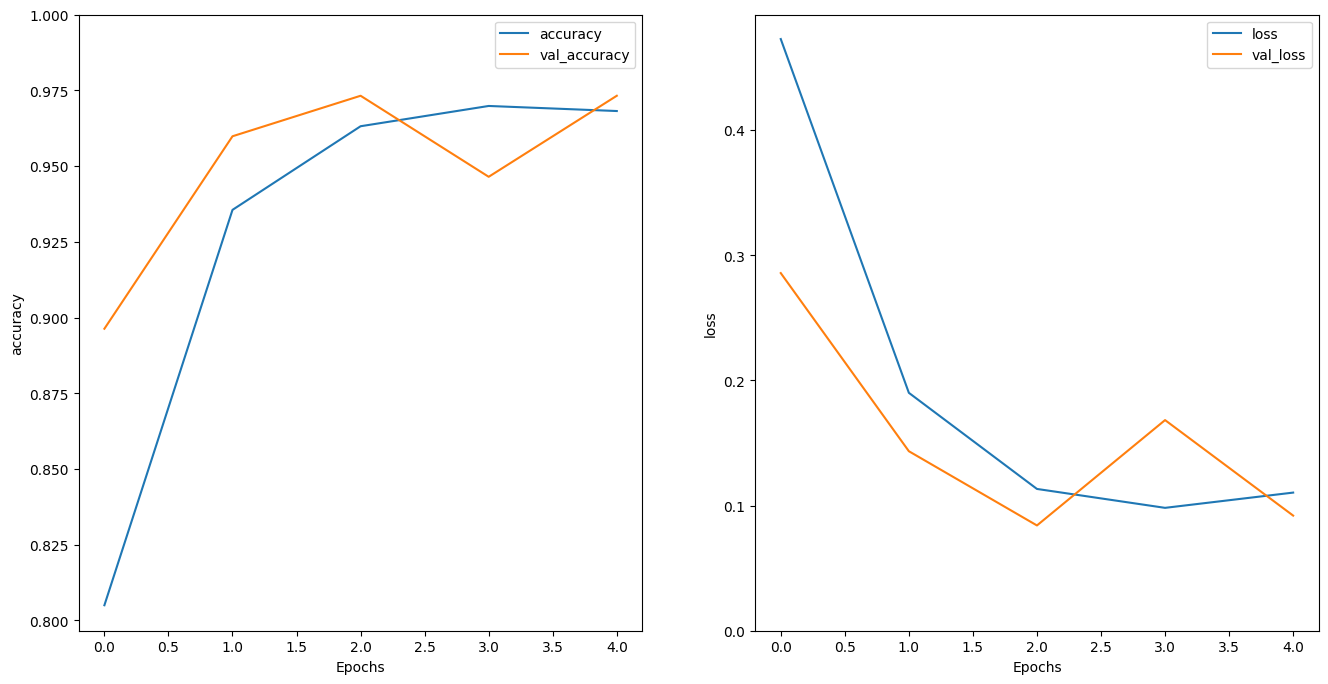

In [42]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

#### Avaliação do Modelo

In [43]:
loss_lstm3, acc_lstm3 = model.evaluate(testing_padded, y_test)
print(f"LSTM model loss: {loss_lstm3} " )
print(f"LSTM model accuracy: {acc_lstm3*100:0.2f}%" )

10/10 [==============================] - 0s 17ms/step - loss: 0.0920 - accuracy: 0.9732
LSTM model loss: 0.09197113662958145 
LSTM model accuracy: 97.32%


#### Predição

In [44]:
# 'ham' se predict < 0.5 senão 'spam'
predict_spam(predict_msg)

1/1 [==============================] - 1s 879ms/step


array([[0.7193989 ],
       [0.03049822]], dtype=float32)

In [45]:
### TERMINE O CÓDIGO AQUI ###

## Desafio 2

Modifique a configuração do modelo de classificação de forma a usar uma Gated Recurrent Unit (GRU) Bidirecional, em vez de uma LSTM.

Você vai precisar replicar todas as células do notebook, desde a Configuração do Modelo de Classificação, fazendo as devidas adaptações para a nova configuração.

A saída esperada para o model.sumary() da nova arquitetura é:

Adicione abaixo a nova sequência de código.

In [46]:
### INICIE O CÓDIGO AQUI ### (várias linhas de código / várias células)

#### Configuração do Modelo de Classificação

In [47]:
model = Sequential()
model.add(Embedding(vocab_size,
                    embedding_dim,
                    input_length = max_len))
model.add(Bidirectional(GRU(128)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 50, 16)            8000      
                                                                 
 bidirectional_4 (Bidirecti  (None, 256)               112128    
 onal)                                                           
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 1)                 257       
                                                                 
Total params: 120385 (470.25 KB)
Trainable params: 120385 (470.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [48]:
model.compile(loss = 'binary_crossentropy',
                   optimizer = 'adam',
                   metrics=['accuracy'])

#### Treinamento do Modelo

In [49]:
history = model.fit(training_padded,
                    y_train,
                    epochs = num_epochs,
                    validation_data = (testing_padded, y_test),
                    callbacks = [early_stop],
                    verbose = 2)

Epoch 1/30
38/38 - 3s - loss: 0.6379 - accuracy: 0.6594 - val_loss: 0.4348 - val_accuracy: 0.8328 - 3s/epoch - 77ms/step
Epoch 2/30
38/38 - 1s - loss: 0.3067 - accuracy: 0.8954 - val_loss: 0.2334 - val_accuracy: 0.9398 - 511ms/epoch - 13ms/step
Epoch 3/30
38/38 - 1s - loss: 0.1534 - accuracy: 0.9498 - val_loss: 0.1181 - val_accuracy: 0.9599 - 547ms/epoch - 14ms/step
Epoch 4/30
38/38 - 1s - loss: 0.1203 - accuracy: 0.9649 - val_loss: 0.0912 - val_accuracy: 0.9699 - 963ms/epoch - 25ms/step
Epoch 5/30
38/38 - 1s - loss: 0.0886 - accuracy: 0.9707 - val_loss: 0.0973 - val_accuracy: 0.9632 - 551ms/epoch - 15ms/step
Epoch 6/30
38/38 - 1s - loss: 0.0743 - accuracy: 0.9774 - val_loss: 0.0830 - val_accuracy: 0.9632 - 610ms/epoch - 16ms/step
Epoch 7/30
38/38 - 1s - loss: 0.0546 - accuracy: 0.9858 - val_loss: 0.0788 - val_accuracy: 0.9666 - 902ms/epoch - 24ms/step
Epoch 8/30
38/38 - 1s - loss: 0.0443 - accuracy: 0.9849 - val_loss: 0.0745 - val_accuracy: 0.9732 - 507ms/epoch - 13ms/step
Epoch 9/30


(0.0, 0.6677176654338837)

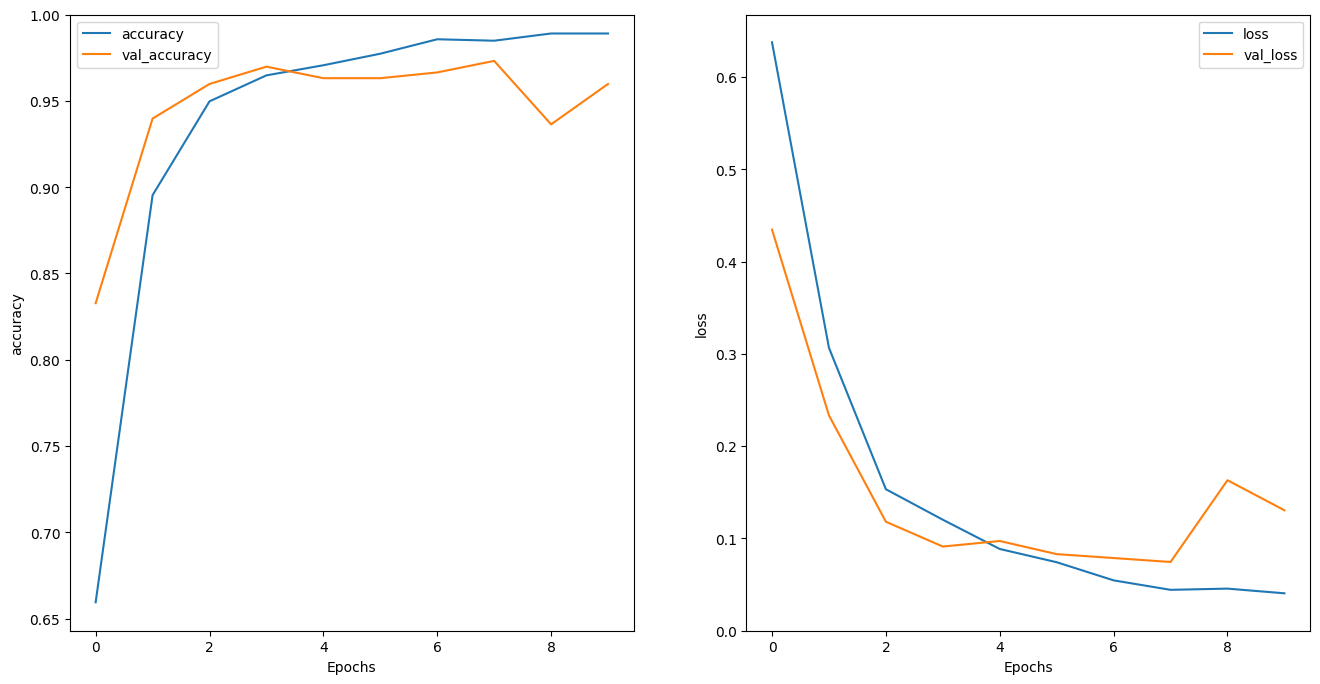

In [50]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

#### Avaliação do Modelo

In [51]:
loss_gru, acc_gru = model.evaluate(testing_padded, y_test)
print(f"GRU model loss: {loss_gru} " )
print(f"GRU model accuracy: {acc_gru*100:0.2f}%" )

10/10 [==============================] - 0s 4ms/step - loss: 0.1306 - accuracy: 0.9599
GRU model loss: 0.13056044280529022 
GRU model accuracy: 95.99%


#### Predição

In [52]:
# 'ham' se predict < 0.5 senão 'spam'
predict_spam(predict_msg)

1/1 [==============================] - 0s 282ms/step


array([[0.98669106],
       [0.03778293]], dtype=float32)

In [53]:
### TERMINE O CÓDIGO AQUI ###

## Comparação dos Resultados

Adicione abaixo uma tabela com a comparação dos resultados obtidos pelas três configurações efetuadas neste notebook.<br>
Qual configuração obteve o melhor resultados?

In [54]:
### ADICIONE A TABELA DE RESULTADOS AQUI ###
results = pd.DataFrame({
    'Configuração': ['LSTM Bidirecional (1 camada)',
                      'LSTM Bidirecional (3 camadas)',
                      'GRU Bidirecional (1 camada)'],
    'Perda (Loss)': [loss_lstm1, loss_lstm3, loss_gru],
    'Acurácia (%)': [acc_lstm1 * 100, acc_lstm3 * 100, acc_gru * 100]
})

# Ordena da melhor para a pior acurácia
results = results.sort_values(by='Acurácia (%)', ascending=False).reset_index(drop=True)
display(results)

best_config = results.loc[0, 'Configuração']
print(f"\nA configuração com o melhor resultado foi: {best_config}")

,Configuração,Perda (Loss),Acurácia (%)
0,LSTM Bidirecional (3 camadas),0.091971,97.324413
1,GRU Bidirecional (1 camada),0.130560,95.986623
2,LSTM Bidirecional (1 camada),0.193219,94.314378



A configuração com o melhor resultado foi: LSTM Bidirecional (3 camadas)


# Fim

Parabéns! Você efetuou todos os passos para criar modelos baseados em Redes Neurais Recorrentes para a tarefa de classificação de textos.

-------------------------------------------